# Perhitungan Manual Doc2Vec **PV-DBOW**

Notebook ini melakukan simulasi perhitungan manual dari arsitektur **Paragraph
Vector – Distributed Bag of Words (PV-DBOW)** sesuai landasan teori pada Bab&nbsp;2.
Tujuannya adalah memperlihatkan **setiap langkah** dari proses pelatihan, mulai
dari representasi *one-hot*, transformasi ke *hidden layer*, proyeksi ke *output
layer*, normalisasi *softmax*, perhitungan *cross-entropy loss*, sampai
pembaruan bobot **D** (matriks dokumen) dan **W** (matriks kata) menggunakan
*Stochastic Gradient Descent* (SGD) – dilakukan **per kata** di dalam epoch
pertama dan epoch kedua, lalu disusul oleh seluruh sisa epoch sampai epoch
ke-40.

### Notasi yang dipakai

| Simbol | Ukuran | Arti |
|---|---|---|
| $d$ | skalar | Jumlah dokumen di korpus ($d=10$, doc0–doc9) |
| $V$ | skalar | Ukuran kosakata ($V=4$) |
| $n$ | skalar | Dimensi vektor *embedding* ($n=3$) |
| $\eta$ | skalar | *Learning rate* ($\eta=0{,}05$) |
| $p_t$ | $1\times d$ | *One-hot* untuk ID dokumen ke-$t$ |
| $t_w$ | $1\times V$ | *One-hot* untuk kata target ke-$w$ |
| $D$ | $d\times n$ | Matriks paragraf (baris = satu dokumen) |
| $W$ | $n\times V$ | Matriks kata (kolom = satu kata) |
| $v_c$ | $1\times n$ | Vektor paragraf pada *hidden layer* |
| $u_o$ | $1\times V$ | Skor mentah (*logits*) pada *output layer* |
| $y$ | $1\times V$ | Distribusi probabilitas hasil *softmax* |

### Tahapan PV-DBOW (rumus inti)

$$\boxed{\;v_c = p_t \cdot D \;}\qquad\text{(baris }t\text{ dari }D\text{)}$$

$$u_o = v_c \cdot W$$

$$p(o\mid c) = y_o = \frac{\exp(u_o^{\top} v_c)}{\displaystyle\sum_{w\in V}\exp(u_w^{\top} v_c)}$$

$$L = -\sum_{i=1}^{V} t_i\,\log(y_i)$$

Gradien yang dipakai untuk *backpropagation* (turunan parsial loss
*cross-entropy* + *softmax*):

$$\frac{\partial L}{\partial u_o} = y - t_w$$

$$\frac{\partial L}{\partial W} = v_c^{\top}\,(y - t_w)\quad(\text{matriks }n\times V)$$

$$\frac{\partial L}{\partial v_c} = (y - t_w)\,W^{\top}\quad(\text{vektor }1\times n)$$

Pembaruan SGD dengan *learning rate* $\eta$:

$$W \leftarrow W - \eta\,\frac{\partial L}{\partial W},\qquad
D_{t,:} \leftarrow D_{t,:} - \eta\,\frac{\partial L}{\partial v_c}$$


## 1. Parameter Inisialisasi (Tabel&nbsp;3.13)

| Parameter | Nilai | Keterangan |
|---|---|---|
| `vector_size` ($n$) | **3** | Dimensi vektor *embedding* dokumen & kata |
| `epochs` | **40** | Jumlah iterasi pelatihan |
| `learning_rate` ($\eta$) | **0.05** | Kecepatan pembaruan bobot |

## 2. Kosakata (Tabel&nbsp;3.14)

| Indeks ($w$) | Kata (Token) | Dokumen Asal |
|---|---|---|
| 0 | `make` | doc0 |
| 1 | `sens` | doc0 |
| 2 | `pickk` | doc5 |
| 3 | `meeeeeee` | doc5 |

## 3. Inisialisasi Matriks $D$ dan $W$ (Tabel&nbsp;3.15 – 3.16)

**Matriks $D$ (10 × 3)** &nbsp; — &nbsp; doc0 dan doc5 sesuai tabel pada Bab&nbsp;3.
Untuk doc1–doc4 dan doc6–doc9 diberikan inisialisasi linear deterministik agar
mudah direproduksi (sebagaimana di dokumen ini tidak menjadi sumber kata
*vocabulary*, maka pembaruan terhadap baris tersebut tidak terjadi).

| Dokumen | $n_1$ | $n_2$ | $n_3$ |
|---|---|---|---|
| doc0 | 0.1000 | 0.2000 | 0.3000 |
| doc1 | 0.1500 | 0.2500 | 0.3500 |
| doc2 | 0.2000 | 0.3000 | 0.4000 |
| doc3 | 0.2500 | 0.3500 | 0.4500 |
| doc4 | 0.3000 | 0.4000 | 0.5000 |
| doc5 | 0.4000 | 0.5000 | 0.6000 |
| doc6 | 0.4500 | 0.5500 | 0.6500 |
| doc7 | 0.5000 | 0.6000 | 0.7000 |
| doc8 | 0.5500 | 0.6500 | 0.7500 |
| doc9 | 0.6000 | 0.7000 | 0.8000 |

**Matriks $W$ (3 × 4)**

| Dim. Hidden | `make` ($w_0$) | `sens` ($w_1$) | `pickk` ($w_2$) | `meeeeeee` ($w_3$) |
|---|---|---|---|---|
| $n_1$ | 0.1000 | 0.2000 | 0.3000 | 0.4000 |
| $n_2$ | 0.5000 | 0.6000 | 0.7000 | 0.8000 |
| $n_3$ | 0.9000 | 0.1000 | 0.2000 | 0.3000 |


In [1]:
# === Setup library dan parameter ===
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registrasi proyeksi 3d)

np.set_printoptions(precision=4, suppress=True, linewidth=120)

# --- Parameter (Tabel 3.13) ---
N = 3            # vector_size (n)
EPOCHS = 40
LR = 0.05        # learning_rate (eta)

# --- Vocabulary (Tabel 3.14) ---
vocab = ['make', 'sens', 'pickk', 'meeeeeee']
V = len(vocab)
word_to_idx = {w: i for i, w in enumerate(vocab)}

# --- Dokumen (10 dokumen: doc0..doc9) ---
doc_names = [f'doc{i}' for i in range(10)]
DOCS = len(doc_names)
doc_to_idx = {n: i for i, n in enumerate(doc_names)}

# --- Pasangan pelatihan manual (Tabel 3.14 – kata berasal dari doc0 & doc5) ---
training_pairs = [
    (doc_to_idx['doc0'], word_to_idx['make']),
    (doc_to_idx['doc0'], word_to_idx['sens']),
    (doc_to_idx['doc5'], word_to_idx['pickk']),
    (doc_to_idx['doc5'], word_to_idx['meeeeeee']),
]

print('Parameter :')
print(f'  n (vector_size) = {N}')
print(f'  epochs          = {EPOCHS}')
print(f'  eta             = {LR}')
print(f'  d (jumlah doc)  = {DOCS}')
print(f'  V (vocab size)  = {V}')
print(f'\nVocab         : {vocab}')
print(f'Doc list      : {doc_names}')
print(f'Training pairs: {[(doc_names[d], vocab[w]) for d, w in training_pairs]}')

Parameter :
  n (vector_size) = 3
  epochs          = 40
  eta             = 0.05
  d (jumlah doc)  = 10
  V (vocab size)  = 4

Vocab         : ['make', 'sens', 'pickk', 'meeeeeee']
Doc list      : ['doc0', 'doc1', 'doc2', 'doc3', 'doc4', 'doc5', 'doc6', 'doc7', 'doc8', 'doc9']
Training pairs: [('doc0', 'make'), ('doc0', 'sens'), ('doc5', 'pickk'), ('doc5', 'meeeeeee')]


In [2]:
# === Inisialisasi matriks D (10x3) dan W (3x4) ===
D = np.array([
    [0.10, 0.20, 0.30],   # doc0
    [0.15, 0.25, 0.35],   # doc1
    [0.20, 0.30, 0.40],   # doc2
    [0.25, 0.35, 0.45],   # doc3
    [0.30, 0.40, 0.50],   # doc4
    [0.40, 0.50, 0.60],   # doc5
    [0.45, 0.55, 0.65],   # doc6
    [0.50, 0.60, 0.70],   # doc7
    [0.55, 0.65, 0.75],   # doc8
    [0.60, 0.70, 0.80],   # doc9
], dtype=float)

W = np.array([
    [0.1, 0.2, 0.3, 0.4],   # n1
    [0.5, 0.6, 0.7, 0.8],   # n2
    [0.9, 0.1, 0.2, 0.3],   # n3
], dtype=float)

# Simpan kondisi awal untuk perbandingan akhir
D_init = D.copy()
W_init = W.copy()

print('Matriks D awal (10 x 3):')
print(D)
print('\nMatriks W awal (3 x 4):')
print(W)

Matriks D awal (10 x 3):
[[0.1  0.2  0.3 ]
 [0.15 0.25 0.35]
 [0.2  0.3  0.4 ]
 [0.25 0.35 0.45]
 [0.3  0.4  0.5 ]
 [0.4  0.5  0.6 ]
 [0.45 0.55 0.65]
 [0.5  0.6  0.7 ]
 [0.55 0.65 0.75]
 [0.6  0.7  0.8 ]]

Matriks W awal (3 x 4):
[[0.1 0.2 0.3 0.4]
 [0.5 0.6 0.7 0.8]
 [0.9 0.1 0.2 0.3]]


## 4. Fungsi Pembantu (Forward, Softmax, Backprop, SGD Update)

Setiap fungsi di bawah ini mengimplementasikan satu blok matematis dari
PV-DBOW sehingga jejak nilainya bisa diperlihatkan dengan jelas pada setiap
langkah per kata.


In [3]:
def one_hot(idx: int, size: int) -> np.ndarray:
    # Membentuk vektor one-hot ukuran `size` dengan 1 pada posisi `idx`.
    v = np.zeros(size, dtype=int)
    v[idx] = 1
    return v


def softmax(u: np.ndarray) -> np.ndarray:
    # Softmax sesuai rumus pada landasan teori:
    #   y_o = exp(u_o) / sum_w exp(u_w)
    e = np.exp(u)
    return e / e.sum()


def cross_entropy(y: np.ndarray, target_idx: int) -> float:
    # L = -sum t_i log(y_i)
    # Karena t adalah one-hot pada posisi `target_idx`, maka L = -log(y[target_idx]).
    return float(-np.log(y[target_idx]))


def forward(D: np.ndarray, W: np.ndarray, doc_idx: int):
    # Forward pass PV-DBOW untuk satu pasangan (dokumen, kata).
    v_c = D[doc_idx].copy()           # 1 x n  (memilih baris doc_idx dari D)
    u_o = v_c @ W                     # 1 x V  (logits)
    y = softmax(u_o)                  # 1 x V  (probabilitas)
    return v_c, u_o, y


def backward(v_c: np.ndarray, y: np.ndarray, target_idx: int, W: np.ndarray):
    # Backpropagation: gradien terhadap W dan v_c.
    t_w = one_hot(target_idx, V).astype(float)
    grad_uo = y - t_w                       # 1 x V
    grad_W = np.outer(v_c, grad_uo)         # n x V
    grad_vc = grad_uo @ W.T                 # 1 x n
    return grad_uo, grad_W, grad_vc, t_w


def sgd_update(D, W, doc_idx, grad_W, grad_vc, lr):
    # Pembaruan SGD terhadap W (keseluruhan) dan D pada baris doc_idx saja.
    W_new = W - lr * grad_W
    D_new = D.copy()
    D_new[doc_idx] = D[doc_idx] - lr * grad_vc
    return D_new, W_new

In [4]:
def detailed_step(epoch_num, step_num, doc_idx, word_idx, D, W, lr):
    # Lakukan satu langkah SGD penuh dan cetak SEMUA detail perhitungannya
    # (input one-hot -> hidden -> output -> softmax -> loss -> gradien -> update SGD).

    title = f"STEP {epoch_num}.{step_num} | EPOCH {epoch_num} | {doc_names[doc_idx]} \u2192 '{vocab[word_idx]}' (w{word_idx})"
    print('=' * 78)
    print(title)
    print('=' * 78)

    # --- Input layer (one-hot) ---
    p_t = one_hot(doc_idx, DOCS)
    t_w = one_hot(word_idx, V)
    print(f"\n[1] INPUT LAYER (one-hot vectors)")
    print(f"    p_t  (1 x d={DOCS})  = {p_t.tolist()}  -> dokumen '{doc_names[doc_idx]}'")
    print(f"    t_w  (1 x V={V})   = {t_w.tolist()}                  -> target  '{vocab[word_idx]}'")

    # --- Hidden layer: v_c = p_t . D ---
    v_c = D[doc_idx].copy()
    print(f"\n[2] HIDDEN LAYER   v_c = p_t . D  (rumus: v_c = D . p_t^T)")
    print(f"    Karena p_t one-hot pada posisi {doc_idx}, hasilnya = baris ke-{doc_idx} dari D")
    print(f"    v_c = D[{doc_idx}] = {v_c}")

    # --- Output layer: u_o = v_c . W ---
    u_o = v_c @ W
    print(f"\n[3] OUTPUT LAYER   u_o = v_c . W   (shape 1 x V = 1 x {V})")
    for k in range(V):
        terms = ' + '.join([f"{v_c[j]:.4f}*{W[j,k]:.4f}" for j in range(N)])
        print(f"    u_o[{k}] ({vocab[k]:>10}) = {terms} = {u_o[k]:.6f}")
    print(f"    u_o = {u_o}")

    # --- Softmax ---
    e = np.exp(u_o)
    s = e.sum()
    y = e / s
    print(f"\n[4] SOFTMAX        y_o = exp(u_o[o]) / \u03a3_w exp(u_o[w])")
    for k in range(V):
        print(f"    exp(u_o[{k}]) = exp({u_o[k]:.6f}) = {e[k]:.6f}")
    print(f"    \u03a3 exp(u_o) = {s:.6f}")
    for k in range(V):
        print(f"    y[{k}] ({vocab[k]:>10}) = {e[k]:.6f} / {s:.6f} = {y[k]:.6f}")
    print(f"    y = {y}")

    # --- Loss ---
    L = cross_entropy(y, word_idx)
    print(f"\n[5] LOSS           L = -\u03a3 t_i log(y_i) = -log(y[target={word_idx}])")
    print(f"    L = -log({y[word_idx]:.6f}) = {L:.6f}")

    # --- Backprop ---
    grad_uo = y - t_w
    print(f"\n[6] GRADIEN OUTPUT \u2202L/\u2202u_o = y - t_w")
    print(f"    \u2202L/\u2202u_o = {y} - {t_w.astype(float).tolist()}")
    print(f"             = {grad_uo}")

    grad_W = np.outer(v_c, grad_uo)
    print(f"\n[7] GRADIEN W      \u2202L/\u2202W = v_c^T \u00b7 (y - t_w)   (shape n x V = {N} x {V})")
    for i in range(N):
        row = ' , '.join([f"{v_c[i]:.4f}*{grad_uo[k]:.6f} = {grad_W[i,k]:+.6f}" for k in range(V)])
        print(f"    baris n{i+1}: {row}")
    print(f"    \u2202L/\u2202W =\n{grad_W}")

    grad_vc = grad_uo @ W.T
    print(f"\n[8] GRADIEN v_c    \u2202L/\u2202v_c = (y - t_w) . W^T   (shape 1 x n = 1 x {N})")
    for i in range(N):
        row = ' + '.join([f"{grad_uo[k]:+.6f}*{W[i,k]:.4f}" for k in range(V)])
        print(f"    \u2202L/\u2202v_c[{i}] (n{i+1}) = {row} = {grad_vc[i]:+.6f}")
    print(f"    \u2202L/\u2202v_c = {grad_vc}")

    # --- SGD update ---
    print(f"\n[9] UPDATE SGD     \u03b7 = {lr}")
    print(f"    W \u2190 W - \u03b7 . \u2202L/\u2202W")
    print(f"      W (sebelum):\n{W}")
    W_new = W - lr * grad_W
    print(f"      W (sesudah):\n{W_new}")
    print(f"    D[{doc_idx}] \u2190 D[{doc_idx}] - \u03b7 . \u2202L/\u2202v_c")
    print(f"      D[{doc_idx}] (sebelum): {D[doc_idx]}")
    D_new = D.copy()
    D_new[doc_idx] = D[doc_idx] - lr * grad_vc
    print(f"      D[{doc_idx}] (sesudah): {D_new[doc_idx]}")

    print()  # baris kosong di akhir
    return D_new, W_new, L

## 5. Detail Perhitungan **Epoch 1** (Per Kata)

Pelatihan dilakukan dengan urutan pasangan (dokumen, kata) berikut:

1. (`doc0`, `make`)
2. (`doc0`, `sens`)
3. (`doc5`, `pickk`)
4. (`doc5`, `meeeeeee`)

Pada setiap langkah, **kedua** matriks $W$ dan baris yang sesuai pada $D$
diperbarui menggunakan SGD seperti yang ditunjukkan pada blok rumus berikut:

$$W \leftarrow W - \eta\,v_c^{\top}\,(y - t_w),\qquad
D_{t,:} \leftarrow D_{t,:} - \eta\,(y - t_w)\,W^{\top}$$


In [5]:
# Reset matriks ke kondisi awal (untuk kejelasan, walau sudah di-set di atas).
D = D_init.copy()
W = W_init.copy()
losses_epoch1 = []

### 5.1. Langkah 1.1 – doc0 memprediksi kata **`make`**

In [6]:
D, W, L = detailed_step(1, 1, *training_pairs[0], D=D, W=W, lr=LR)
losses_epoch1.append(L)

STEP 1.1 | EPOCH 1 | doc0 → 'make' (w0)

[1] INPUT LAYER (one-hot vectors)
    p_t  (1 x d=10)  = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  -> dokumen 'doc0'
    t_w  (1 x V=4)   = [1, 0, 0, 0]                  -> target  'make'

[2] HIDDEN LAYER   v_c = p_t . D  (rumus: v_c = D . p_t^T)
    Karena p_t one-hot pada posisi 0, hasilnya = baris ke-0 dari D
    v_c = D[0] = [0.1 0.2 0.3]

[3] OUTPUT LAYER   u_o = v_c . W   (shape 1 x V = 1 x 4)
    u_o[0] (      make) = 0.1000*0.1000 + 0.2000*0.5000 + 0.3000*0.9000 = 0.380000
    u_o[1] (      sens) = 0.1000*0.2000 + 0.2000*0.6000 + 0.3000*0.1000 = 0.170000
    u_o[2] (     pickk) = 0.1000*0.3000 + 0.2000*0.7000 + 0.3000*0.2000 = 0.230000
    u_o[3] (  meeeeeee) = 0.1000*0.4000 + 0.2000*0.8000 + 0.3000*0.3000 = 0.290000
    u_o = [0.38 0.17 0.23 0.29]

[4] SOFTMAX        y_o = exp(u_o[o]) / Σ_w exp(u_o[w])
    exp(u_o[0]) = exp(0.380000) = 1.462285
    exp(u_o[1]) = exp(0.170000) = 1.185305
    exp(u_o[2]) = exp(0.230000) = 1.258600
    exp(u_o[3]) 

### 5.2. Langkah 1.2 – doc0 memprediksi kata **`sens`**

In [7]:
D, W, L = detailed_step(1, 2, *training_pairs[1], D=D, W=W, lr=LR)
losses_epoch1.append(L)

STEP 1.2 | EPOCH 1 | doc0 → 'sens' (w1)

[1] INPUT LAYER (one-hot vectors)
    p_t  (1 x d=10)  = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  -> dokumen 'doc0'
    t_w  (1 x V=4)   = [0, 1, 0, 0]                  -> target  'sens'

[2] HIDDEN LAYER   v_c = p_t . D  (rumus: v_c = D . p_t^T)
    Karena p_t one-hot pada posisi 0, hasilnya = baris ke-0 dari D
    v_c = D[0] = [0.0926 0.1926 0.3251]

[3] OUTPUT LAYER   u_o = v_c . W   (shape 1 x V = 1 x 4)
    u_o[0] (      make) = 0.0926*0.1036 + 0.1926*0.5072 + 0.3251*0.9108 = 0.403411
    u_o[1] (      sens) = 0.0926*0.1989 + 0.1926*0.5977 + 0.3251*0.0966 = 0.164983
    u_o[2] (     pickk) = 0.0926*0.2988 + 0.1926*0.6976 + 0.3251*0.1964 = 0.225919
    u_o[3] (  meeeeeee) = 0.0926*0.3987 + 0.1926*0.7975 + 0.3251*0.2962 = 0.286850
    u_o = [0.4034 0.165  0.2259 0.2868]

[4] SOFTMAX        y_o = exp(u_o[o]) / Σ_w exp(u_o[w])
    exp(u_o[0]) = exp(0.403411) = 1.496922
    exp(u_o[1]) = exp(0.164983) = 1.179373
    exp(u_o[2]) = exp(0.225919) = 1.253475

### 5.3. Langkah 1.3 – doc5 memprediksi kata **`pickk`**

In [8]:
D, W, L = detailed_step(1, 3, *training_pairs[2], D=D, W=W, lr=LR)
losses_epoch1.append(L)

STEP 1.3 | EPOCH 1 | doc5 → 'pickk' (w2)

[1] INPUT LAYER (one-hot vectors)
    p_t  (1 x d=10)  = [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  -> dokumen 'doc5'
    t_w  (1 x V=4)   = [0, 0, 1, 0]                  -> target  'pickk'

[2] HIDDEN LAYER   v_c = p_t . D  (rumus: v_c = D . p_t^T)
    Karena p_t one-hot pada posisi 5, hasilnya = baris ke-5 dari D
    v_c = D[5] = [0.4 0.5 0.6]

[3] OUTPUT LAYER   u_o = v_c . W   (shape 1 x V = 1 x 4)
    u_o[0] (      make) = 0.4000*0.1023 + 0.5000*0.5045 + 0.6000*0.9062 = 0.836866
    u_o[1] (      sens) = 0.4000*0.2025 + 0.5000*0.6052 + 0.6000*0.1092 = 0.449124
    u_o[2] (     pickk) = 0.4000*0.2977 + 0.5000*0.6953 + 0.6000*0.1925 = 0.582247
    u_o[3] (  meeeeeee) = 0.4000*0.3976 + 0.5000*0.7950 + 0.6000*0.2921 = 0.731764
    u_o = [0.8369 0.4491 0.5822 0.7318]

[4] SOFTMAX        y_o = exp(u_o[o]) / Σ_w exp(u_o[w])
    exp(u_o[0]) = exp(0.836866) = 2.309118
    exp(u_o[1]) = exp(0.449124) = 1.566939
    exp(u_o[2]) = exp(0.582247) = 1.790056
    ex

### 5.4. Langkah 1.4 – doc5 memprediksi kata **`meeeeeee`**

In [9]:
D, W, L = detailed_step(1, 4, *training_pairs[3], D=D, W=W, lr=LR)
losses_epoch1.append(L)

STEP 1.4 | EPOCH 1 | doc5 → 'meeeeeee' (w3)

[1] INPUT LAYER (one-hot vectors)
    p_t  (1 x d=10)  = [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  -> dokumen 'doc5'
    t_w  (1 x V=4)   = [0, 0, 0, 1]                  -> target  'meeeeeee'

[2] HIDDEN LAYER   v_c = p_t . D  (rumus: v_c = D . p_t^T)
    Karena p_t one-hot pada posisi 5, hasilnya = baris ke-5 dari D
    v_c = D[5] = [0.4025 0.5024 0.5889]

[3] OUTPUT LAYER   u_o = v_c . W   (shape 1 x V = 1 x 4)
    u_o[0] (      make) = 0.4025*0.0963 + 0.5024*0.4970 + 0.5889*0.8972 = 0.816845
    u_o[1] (      sens) = 0.4025*0.1984 + 0.5024*0.6002 + 0.5889*0.1032 = 0.442141
    u_o[2] (     pickk) = 0.4025*0.3131 + 0.5024*0.7145 + 0.5889*0.2156 = 0.611970
    u_o[3] (  meeeeeee) = 0.4025*0.3922 + 0.5024*0.7883 + 0.5889*0.2840 = 0.721170
    u_o = [0.8168 0.4421 0.612  0.7212]

[4] SOFTMAX        y_o = exp(u_o[o]) / Σ_w exp(u_o[w])
    exp(u_o[0]) = exp(0.816845) = 2.263348
    exp(u_o[1]) = exp(0.442141) = 1.556035
    exp(u_o[2]) = exp(0.611970) = 

### 5.5. Recap Akhir **Epoch 1**

Setelah keempat pasangan kata dilatih, berikut adalah ringkasan kondisi
matriks $D$ (untuk seluruh 10 dokumen) dan matriks $W$ pada akhir epoch ke-1.


In [10]:
print(f'Loss per langkah  : {[f"{l:.6f}" for l in losses_epoch1]}')
print(f'Total loss epoch 1: {sum(losses_epoch1):.6f}')
print(f'Rata-rata loss    : {sum(losses_epoch1)/len(losses_epoch1):.6f}')

print('\nMatriks D setelah epoch 1 (10 x 3):')
header = f"  {'Dok':<6}{'n1':>10}{'n2':>10}{'n3':>10}"
print(header)
for i, name in enumerate(doc_names):
    print(f"  {name:<6}{D[i,0]:>10.6f}{D[i,1]:>10.6f}{D[i,2]:>10.6f}")

print('\nMatriks W setelah epoch 1 (3 x 4):')
print(f"  {'':<5}{'make':>12}{'sens':>12}{'pickk':>12}{'meeeeeee':>12}")
for i, dim in enumerate(['n1', 'n2', 'n3']):
    print(f"  {dim:<5}{W[i,0]:>12.6f}{W[i,1]:>12.6f}{W[i,2]:>12.6f}{W[i,3]:>12.6f}")

Loss per langkah  : ['1.276821', '1.495527', '1.464782', '1.322681']
Total loss epoch 1: 5.559811
Rata-rata loss    : 1.389953

Matriks D setelah epoch 1 (10 x 3):
  Dok           n1        n2        n3
  doc0    0.090280  0.190215  0.309797
  doc1    0.150000  0.250000  0.350000
  doc2    0.200000  0.300000  0.400000
  doc3    0.250000  0.350000  0.450000
  doc4    0.300000  0.400000  0.500000
  doc5    0.409771  0.509465  0.582519
  doc6    0.450000  0.550000  0.650000
  doc7    0.500000  0.600000  0.700000
  doc8    0.550000  0.650000  0.750000
  doc9    0.600000  0.700000  0.800000

Matriks W setelah epoch 1 (3 x 4):
               make        sens       pickk    meeeeeee
  n1       0.090424    0.194361    0.308266    0.406949
  n2       0.489652    0.595091    0.708526    0.806730
  n3       0.888616    0.097216    0.208560    0.305608


### 5.6. Visualisasi Ruang Semantik (3D) Setelah Epoch 1

Karena $n=3$, vektor dokumen ($D$) dan vektor kata (kolom-kolom $W$) dapat
langsung diplot dalam ruang 3D. Titik biru = vektor paragraf,
panah/marker merah = vektor kata.


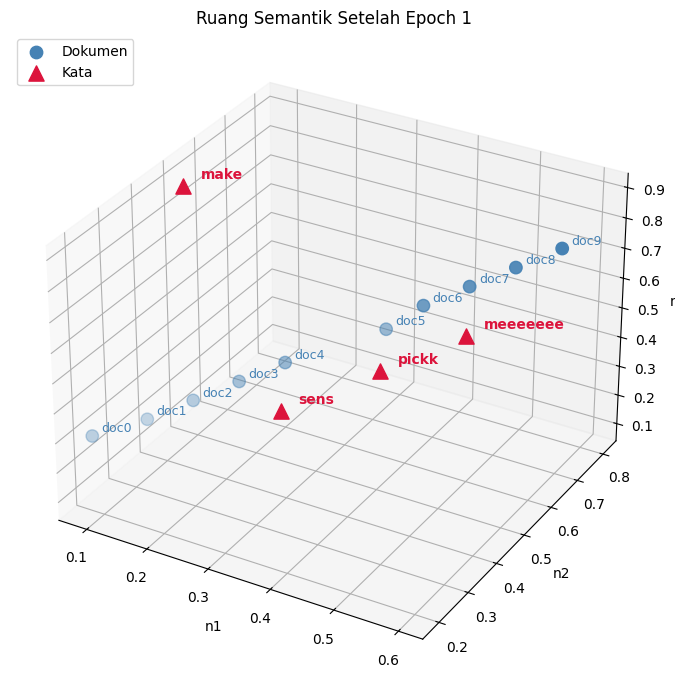

In [11]:
def plot_semantic_space(D, W, title, doc_names, vocab):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')

    # Dokumen
    ax.scatter(D[:, 0], D[:, 1], D[:, 2], c='steelblue', s=80, label='Dokumen')
    for i, name in enumerate(doc_names):
        ax.text(D[i, 0] + 0.01, D[i, 1] + 0.01, D[i, 2] + 0.01,
                name, color='steelblue', fontsize=9)

    # Kata (kolom W)
    for j, w in enumerate(vocab):
        wv = W[:, j]
        ax.scatter(wv[0], wv[1], wv[2], c='crimson', marker='^', s=120,
                   label='Kata' if j == 0 else None)
        ax.text(wv[0] + 0.02, wv[1] + 0.02, wv[2] + 0.02, w,
                color='crimson', fontsize=10, fontweight='bold')

    ax.set_xlabel('n1')
    ax.set_ylabel('n2')
    ax.set_zlabel('n3')
    ax.set_title(title)
    ax.legend(loc='upper left')
    plt.tight_layout()
    plt.show()


plot_semantic_space(D, W, 'Ruang Semantik Setelah Epoch 1', doc_names, vocab)

## 6. Detail Perhitungan **Epoch 2** (Per Kata)

Iterasi kedua menggunakan kondisi $D$ dan $W$ hasil akhir epoch 1 sebagai titik
awal. Urutan kata yang dilatih sama dengan epoch 1.


In [12]:
losses_epoch2 = []

### 6.1. Langkah 2.1 – doc0 memprediksi kata **`make`**

In [13]:
D, W, L = detailed_step(2, 1, *training_pairs[0], D=D, W=W, lr=LR)
losses_epoch2.append(L)

STEP 2.1 | EPOCH 2 | doc0 → 'make' (w0)

[1] INPUT LAYER (one-hot vectors)
    p_t  (1 x d=10)  = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  -> dokumen 'doc0'
    t_w  (1 x V=4)   = [1, 0, 0, 0]                  -> target  'make'

[2] HIDDEN LAYER   v_c = p_t . D  (rumus: v_c = D . p_t^T)
    Karena p_t one-hot pada posisi 0, hasilnya = baris ke-0 dari D
    v_c = D[0] = [0.0903 0.1902 0.3098]

[3] OUTPUT LAYER   u_o = v_c . W   (shape 1 x V = 1 x 4)
    u_o[0] (      make) = 0.0903*0.0904 + 0.1902*0.4897 + 0.3098*0.8886 = 0.376594
    u_o[1] (      sens) = 0.0903*0.1944 + 0.1902*0.5951 + 0.3098*0.0972 = 0.160860
    u_o[2] (     pickk) = 0.0903*0.3083 + 0.1902*0.7085 + 0.3098*0.2086 = 0.227214
    u_o[3] (  meeeeeee) = 0.0903*0.4069 + 0.1902*0.8067 + 0.3098*0.3056 = 0.284868
    u_o = [0.3766 0.1609 0.2272 0.2849]

[4] SOFTMAX        y_o = exp(u_o[o]) / Σ_w exp(u_o[w])
    exp(u_o[0]) = exp(0.376594) = 1.457312
    exp(u_o[1]) = exp(0.160860) = 1.174520
    exp(u_o[2]) = exp(0.227214) = 1.255099

### 6.2. Langkah 2.2 – doc0 memprediksi kata **`sens`**

In [14]:
D, W, L = detailed_step(2, 2, *training_pairs[1], D=D, W=W, lr=LR)
losses_epoch2.append(L)

STEP 2.2 | EPOCH 2 | doc0 → 'sens' (w1)

[1] INPUT LAYER (one-hot vectors)
    p_t  (1 x d=10)  = [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]  -> dokumen 'doc0'
    t_w  (1 x V=4)   = [0, 1, 0, 0]                  -> target  'sens'

[2] HIDDEN LAYER   v_c = p_t . D  (rumus: v_c = D . p_t^T)
    Karena p_t one-hot pada posisi 0, hasilnya = baris ke-0 dari D
    v_c = D[0] = [0.0825 0.1824 0.3343]

[3] OUTPUT LAYER   u_o = v_c . W   (shape 1 x V = 1 x 4)
    u_o[0] (      make) = 0.0825*0.0937 + 0.1824*0.4965 + 0.3343*0.8998 = 0.399076
    u_o[1] (      sens) = 0.0825*0.1933 + 0.1824*0.5929 + 0.3343*0.0937 = 0.155404
    u_o[2] (     pickk) = 0.0825*0.3072 + 0.1824*0.7062 + 0.3343*0.2048 = 0.222594
    u_o[3] (  meeeeeee) = 0.0825*0.4058 + 0.1824*0.8043 + 0.3343*0.3017 = 0.280979
    u_o = [0.3991 0.1554 0.2226 0.281 ]

[4] SOFTMAX        y_o = exp(u_o[o]) / Σ_w exp(u_o[w])
    exp(u_o[0]) = exp(0.399076) = 1.490447
    exp(u_o[1]) = exp(0.155404) = 1.168130
    exp(u_o[2]) = exp(0.222594) = 1.249313

### 6.3. Langkah 2.3 – doc5 memprediksi kata **`pickk`**

In [15]:
D, W, L = detailed_step(2, 3, *training_pairs[2], D=D, W=W, lr=LR)
losses_epoch2.append(L)

STEP 2.3 | EPOCH 2 | doc5 → 'pickk' (w2)

[1] INPUT LAYER (one-hot vectors)
    p_t  (1 x d=10)  = [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  -> dokumen 'doc5'
    t_w  (1 x V=4)   = [0, 0, 1, 0]                  -> target  'pickk'

[2] HIDDEN LAYER   v_c = p_t . D  (rumus: v_c = D . p_t^T)
    Karena p_t one-hot pada posisi 5, hasilnya = baris ke-5 dari D
    v_c = D[5] = [0.4098 0.5095 0.5825]

[3] OUTPUT LAYER   u_o = v_c . W   (shape 1 x V = 1 x 4)
    u_o[0] (      make) = 0.4098*0.0925 + 0.5095*0.4939 + 0.5825*0.8950 = 0.810898
    u_o[1] (      sens) = 0.4098*0.1965 + 0.5095*0.6000 + 0.5825*0.1067 = 0.448397
    u_o[2] (     pickk) = 0.4098*0.3062 + 0.5095*0.7041 + 0.5825*0.2008 = 0.601159
    u_o[3] (  meeeeeee) = 0.4098*0.4048 + 0.5095*0.8020 + 0.5825*0.2974 = 0.747705
    u_o = [0.8109 0.4484 0.6012 0.7477]

[4] SOFTMAX        y_o = exp(u_o[o]) / Σ_w exp(u_o[w])
    exp(u_o[0]) = exp(0.810898) = 2.249928
    exp(u_o[1]) = exp(0.448397) = 1.565799
    exp(u_o[2]) = exp(0.601159) = 1.8242

### 6.4. Langkah 2.4 – doc5 memprediksi kata **`meeeeeee`**

In [16]:
D, W, L = detailed_step(2, 4, *training_pairs[3], D=D, W=W, lr=LR)
losses_epoch2.append(L)

STEP 2.4 | EPOCH 2 | doc5 → 'meeeeeee' (w3)

[1] INPUT LAYER (one-hot vectors)
    p_t  (1 x d=10)  = [0, 0, 0, 0, 0, 1, 0, 0, 0, 0]  -> dokumen 'doc5'
    t_w  (1 x V=4)   = [0, 0, 0, 1]                  -> target  'meeeeeee'

[2] HIDDEN LAYER   v_c = p_t . D  (rumus: v_c = D . p_t^T)
    Karena p_t one-hot pada posisi 5, hasilnya = baris ke-5 dari D
    v_c = D[5] = [0.4126 0.5122 0.5721]

[3] OUTPUT LAYER   u_o = v_c . W   (shape 1 x V = 1 x 4)
    u_o[0] (      make) = 0.4126*0.0866 + 0.5122*0.4865 + 0.5721*0.8866 = 0.792110
    u_o[1] (      sens) = 0.4126*0.1924 + 0.5122*0.5949 + 0.5721*0.1008 = 0.441797
    u_o[2] (     pickk) = 0.4126*0.3219 + 0.5122*0.7235 + 0.5721*0.2231 = 0.631071
    u_o[3] (  meeeeeee) = 0.4126*0.3992 + 0.5122*0.7951 + 0.5721*0.2895 = 0.737580
    u_o = [0.7921 0.4418 0.6311 0.7376]

[4] SOFTMAX        y_o = exp(u_o[o]) / Σ_w exp(u_o[w])
    exp(u_o[0]) = exp(0.792110) = 2.208050
    exp(u_o[1]) = exp(0.441797) = 1.555500
    exp(u_o[2]) = exp(0.631071) = 

### 6.5. Recap Akhir **Epoch 2**

In [17]:
print(f'Loss per langkah  : {[f"{l:.6f}" for l in losses_epoch2]}')
print(f'Total loss epoch 2: {sum(losses_epoch2):.6f}')
print(f'Rata-rata loss    : {sum(losses_epoch2)/len(losses_epoch2):.6f}')

print('\nMatriks D setelah epoch 2 (10 x 3):')
header = f"  {'Dok':<6}{'n1':>10}{'n2':>10}{'n3':>10}"
print(header)
for i, name in enumerate(doc_names):
    print(f"  {name:<6}{D[i,0]:>10.6f}{D[i,1]:>10.6f}{D[i,2]:>10.6f}")

print('\nMatriks W setelah epoch 2 (3 x 4):')
print(f"  {'':<5}{'make':>12}{'sens':>12}{'pickk':>12}{'meeeeeee':>12}")
for i, dim in enumerate(['n1', 'n2', 'n3']):
    print(f"  {dim:<5}{W[i,0]:>12.6f}{W[i,1]:>12.6f}{W[i,2]:>12.6f}{W[i,3]:>12.6f}")

Loss per langkah  : ['1.275236', '1.499450', '1.446806', '1.308052']
Total loss epoch 2: 5.529543
Rata-rata loss    : 1.382386

Matriks D setelah epoch 2 (10 x 3):
  Dok           n1        n2        n3
  doc0    0.079827  0.179700  0.318879
  doc1    0.150000  0.250000  0.350000
  doc2    0.200000  0.300000  0.400000
  doc3    0.250000  0.350000  0.450000
  doc4    0.300000  0.400000  0.500000
  doc5    0.420118  0.519518  0.566261
  doc6    0.450000  0.550000  0.650000
  doc7    0.500000  0.600000  0.700000
  doc8    0.550000  0.650000  0.750000
  doc9    0.600000  0.700000  0.800000

Matriks W setelah epoch 2 (3 x 4):
               make        sens       pickk    meeeeeee
  n1       0.080666    0.188259    0.316849    0.414227
  n2       0.479204    0.589736    0.717315    0.813745
  n3       0.878397    0.095077    0.216162    0.310364


### 6.6. Visualisasi Ruang Semantik Setelah Epoch 2

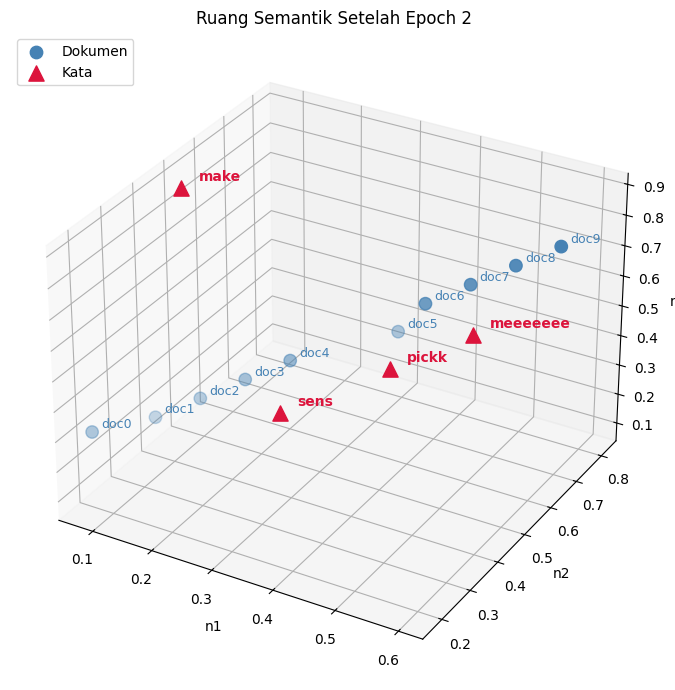

In [18]:
plot_semantic_space(D, W, 'Ruang Semantik Setelah Epoch 2', doc_names, vocab)

## 7. Pelatihan Lanjutan – Epoch 3 sampai 40

Mulai dari epoch ke-3 dan seterusnya, perhitungan tetap mengikuti rumus yang
sama persis, namun ditampilkan secara ringkas (loss per epoch) supaya
notebook tidak terlalu panjang. Semua pembaruan ($D$ dan $W$) tetap
dilakukan persis seperti pada epoch 1 dan 2.


In [19]:
loss_history = [sum(losses_epoch1), sum(losses_epoch2)]

for epoch in range(3, EPOCHS + 1):
    total_L = 0.0
    for doc_idx, word_idx in training_pairs:
        v_c, u_o, y = forward(D, W, doc_idx)
        L = cross_entropy(y, word_idx)
        grad_uo, grad_W, grad_vc, _ = backward(v_c, y, word_idx, W)
        D, W = sgd_update(D, W, doc_idx, grad_W, grad_vc, LR)
        total_L += L
    loss_history.append(total_L)
    if epoch <= 5 or epoch % 5 == 0 or epoch == EPOCHS:
        print(f'Epoch {epoch:>3d} | total loss = {total_L:.6f} | rata-rata = {total_L/4:.6f}')

print(f'\nSelesai. Total epoch dilatih: {EPOCHS}')

Epoch   3 | total loss = 5.499466 | rata-rata = 1.374867
Epoch   4 | total loss = 5.468999 | rata-rata = 1.367250
Epoch   5 | total loss = 5.437623 | rata-rata = 1.359406
Epoch  10 | total loss = 5.252013 | rata-rata = 1.313003
Epoch  15 | total loss = 4.990217 | rata-rata = 1.247554
Epoch  20 | total loss = 4.643104 | rata-rata = 1.160776
Epoch  25 | total loss = 4.252659 | rata-rata = 1.063165
Epoch  30 | total loss = 3.892256 | rata-rata = 0.973064
Epoch  35 | total loss = 3.611007 | rata-rata = 0.902752
Epoch  40 | total loss = 3.412898 | rata-rata = 0.853224

Selesai. Total epoch dilatih: 40


### 7.1. Kurva Loss Sepanjang Epoch 1 – 40

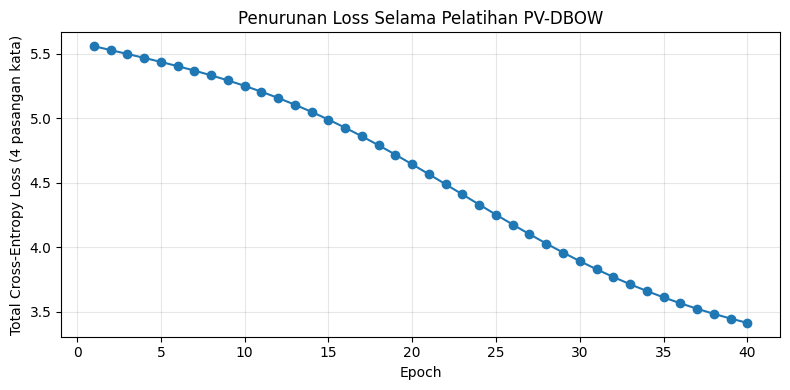

In [20]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, EPOCHS + 1), loss_history, marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('Total Cross-Entropy Loss (4 pasangan kata)')
ax.set_title('Penurunan Loss Selama Pelatihan PV-DBOW')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Hasil Akhir Setelah **Epoch 40**

### 8.1. Matriks $D$ dan $W$ akhir


In [21]:
print('Matriks D AKHIR setelah 40 epoch (10 x 3):')
header = f"  {'Dok':<6}{'n1':>10}{'n2':>10}{'n3':>10}"
print(header)
for i, name in enumerate(doc_names):
    print(f"  {name:<6}{D[i,0]:>10.6f}{D[i,1]:>10.6f}{D[i,2]:>10.6f}")

print('\nMatriks W AKHIR setelah 40 epoch (3 x 4):')
print(f"  {'':<5}{'make':>12}{'sens':>12}{'pickk':>12}{'meeeeeee':>12}")
for i, dim in enumerate(['n1', 'n2', 'n3']):
    print(f"  {dim:<5}{W[i,0]:>12.6f}{W[i,1]:>12.6f}{W[i,2]:>12.6f}{W[i,3]:>12.6f}")

print('\nPergeseran D dari awal (delta = D_akhir - D_awal):')
delta_D = D - D_init
for i, name in enumerate(doc_names):
    print(f"  {name:<6} \u0394 = {delta_D[i]}")


Matriks D AKHIR setelah 40 epoch (10 x 3):
  Dok           n1        n2        n3
  doc0   -0.723053 -0.601448  0.482419
  doc1    0.150000  0.250000  0.350000
  doc2    0.200000  0.300000  0.400000
  doc3    0.250000  0.350000  0.450000
  doc4    0.300000  0.400000  0.500000
  doc5    0.988126  1.067398  0.272408
  doc6    0.450000  0.550000  0.650000
  doc7    0.500000  0.600000  0.700000
  doc8    0.550000  0.650000  0.750000
  doc9    0.600000  0.700000  0.800000

Matriks W AKHIR setelah 40 epoch (3 x 4):
               make        sens       pickk    meeeeeee
  n1      -0.341130   -0.358993    0.830897    0.869226
  n2       0.055275    0.090248    1.213642    1.240836
  n3       0.815508    0.281295    0.181405    0.221792

Pergeseran D dari awal (delta = D_akhir - D_awal):
  doc0   Δ = [-0.8231 -0.8014  0.1824]
  doc1   Δ = [0. 0. 0.]
  doc2   Δ = [0. 0. 0.]
  doc3   Δ = [0. 0. 0.]
  doc4   Δ = [0. 0. 0.]
  doc5   Δ = [ 0.5881  0.5674 -0.3276]
  doc6   Δ = [0. 0. 0.]
  doc7   Δ 

### 8.2. Visualisasi Ruang Semantik Setelah Epoch 40

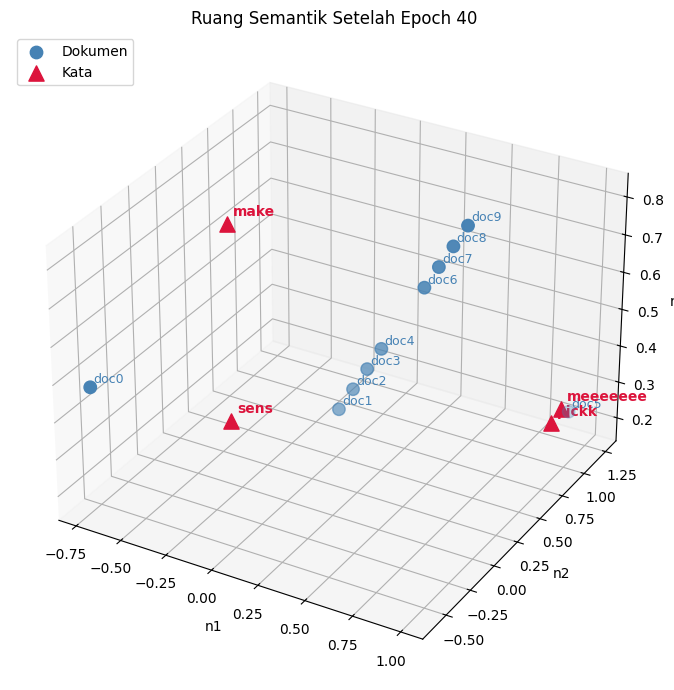

In [22]:
plot_semantic_space(D, W, 'Ruang Semantik Setelah Epoch 40', doc_names, vocab)

### 8.3. Verifikasi Kualitatif: Probabilitas Softmax Akhir

Untuk memeriksa apakah pelatihan sudah mendorong setiap dokumen 'sumber'
ke arah kata-kata targetnya, kita hitung kembali $y = \mathrm{softmax}(D_t W)$
untuk doc0 dan doc5 menggunakan matriks akhir.


In [23]:
for doc_name in ['doc0', 'doc5']:
    d_i = doc_to_idx[doc_name]
    v_c, u_o, y = forward(D, W, d_i)
    print(f'\n--- {doc_name} ---')
    print(f'v_c       = {v_c}')
    print(f'u_o       = {u_o}')
    for k in range(V):
        print(f'  P({vocab[k]:>10} | {doc_name}) = {y[k]:.6f}')


--- doc0 ---
v_c       = [-0.7231 -0.6014  0.4824]
u_o       = [ 0.6068  0.341  -1.2432 -1.2678]
  P(      make | doc0) = 0.481415
  P(      sens | doc0) = 0.369037
  P(     pickk | doc0) = 0.075693
  P(  meeeeeee | doc0) = 0.073855

--- doc5 ---
v_c       = [0.9881 1.0674 0.2724]
u_o       = [-0.0559 -0.1818  2.1659  2.2438]
  P(      make | doc5) = 0.047445
  P(      sens | doc5) = 0.041834
  P(     pickk | doc5) = 0.437632
  P(  meeeeeee | doc5) = 0.473088


## 9. Catatan untuk Penulisan Bab&nbsp;3

* Setiap nilai pada kolom **"sesudah"** di langkah&nbsp;[9] (Update SGD) bisa
  langsung disalin ke tabel Bab&nbsp;3 sebagai tabel iteratif pembaruan
  matriks $D$ dan $W$.
* Karena kosakata manual hanya berasal dari **doc0** dan **doc5**, hanya
  baris ke-0 dan ke-5 pada $D$ yang berubah; baris lainnya (doc1–doc4 dan
  doc6–doc9) tetap mempertahankan nilai inisialisasi. Hal ini sengaja
  ditampilkan agar matriks $D$ konsisten dengan korpus aslinya (10 dokumen)
  meskipun pelatihan manual hanya menyentuh 2 dokumen.
* Visualisasi 3D di Bagian&nbsp;5.6 dan 6.6 menunjukkan **pergerakan vektor**
  dokumen sumber (`doc0`, `doc5`) saling menjauh dari pusat awal dan
  bergerak ke arah kelompok kata-kata yang relevan, sesuai sifat
  *paragraph embedding* yang menangkap konteks semantik tiap dokumen.
